# Customer Lifetime Value & Customer Scoring

คำนวณ CLV และสร้าง Scoring Model สำหรับจัดลำดับลูกค้า

## 1. โหลดข้อมูล

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fix Thai font rendering — force Tahoma
import matplotlib.font_manager as fm
fm.fontManager.addfont(r'C:\Windows\Fonts\tahoma.ttf')
plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['font.sans-serif'] = ['Tahoma'] + plt.rcParams.get('font.sans-serif', [])
plt.rcParams['axes.unicode_minus'] = False

sns.set_style('whitegrid')


sns.set_style('whitegrid')


sns.set_style('whitegrid')
%matplotlib inline

In [2]:
transactions = pd.read_csv('../data/sample/transactions.csv', parse_dates=['transaction_date'])
customers    = pd.read_csv('../data/sample/customers.csv', parse_dates=['registration_date'])
products     = pd.read_csv('../data/sample/products.csv')

## 2. RFM Analysis

In [3]:
snapshot_date = transactions['transaction_date'].max() + pd.Timedelta(days=1)

rfm = transactions.groupby('customer_id').agg(
    recency=('transaction_date', lambda x: (snapshot_date - x.max()).days),
    frequency=('transaction_id', 'count'),
    monetary=('amount', 'sum')
).reset_index()

rfm['R_quartile'] = pd.qcut(rfm['recency'], 4, labels=['1','2','3','4'])
rfm['F_quartile'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=['4','3','2','1'])
rfm['M_quartile'] = pd.qcut(rfm['monetary'], 4, labels=['4','3','2','1'])
rfm['RFM_score'] = rfm['R_quartile'].astype(str) + rfm['F_quartile'].astype(str) + rfm['M_quartile'].astype(str)
rfm.head()

,customer_id,recency,frequency,monetary,R_quartile,F_quartile,M_quartile,RFM_score
0,C0001,174,16,19696.66,4,3,1,431
1,C0002,23,15,22330.18,1,3,1,131
2,C0003,59,16,19324.58,3,3,1,331
3,C0004,174,16,13937.08,4,3,3,433
4,C0005,105,22,20339.90,3,1,1,311


In [4]:
rfm['RFM_score'] = rfm[['R_quartile','F_quartile','M_quartile']].astype(int).sum(axis=1)
rfm.groupby('RFM_score').agg(count=('customer_id','count'), avg_monetary=('monetary','mean'))

,count,avg_monetary
RFM_score,,
3,31,22783.171290
4,43,22561.831395
5,57,19888.330877
6,57,18902.589474
7,59,16470.390000
8,69,15539.705507
9,67,13136.585224
10,45,11909.249556
11,37,11264.887838


## 3. CLV Calculation (Historical + Predictive)

In [5]:
# Historical CLV — total spend per customer
clv_hist = transactions.groupby('customer_id')['amount'].sum().reset_index()
clv_hist.columns = ['customer_id', 'historical_clv']

# Predictive CLV — Simple BG/NBD-inspired (average spend × frequency × retention proxy)
avg_order = transactions.groupby('customer_id')['amount'].mean().reset_index()
avg_order.columns = ['customer_id', 'avg_order_value']

clv = clv_hist.merge(avg_order, on='customer_id')
clv['predicted_clv_12mo'] = clv['avg_order_value'] * rfm['frequency'] * 0.6  # simplified retention
clv.head()

,customer_id,historical_clv,avg_order_value,predicted_clv_12mo
0,C0001,19696.66,1231.041250,11817.996
1,C0002,22330.18,1488.678667,13398.108
2,C0003,19324.58,1207.786250,11594.748
3,C0004,13937.08,871.067500,8362.248
4,C0005,20339.90,924.540909,12203.940


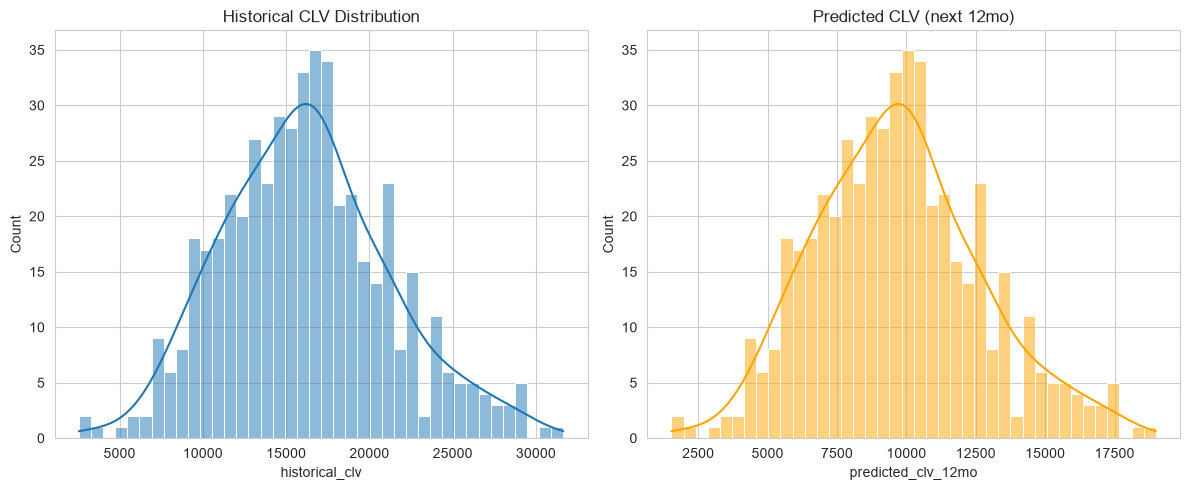

In [6]:
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
sns.histplot(clv['historical_clv'], bins=40, kde=True)
plt.title('Historical CLV Distribution')
plt.subplot(1,2,2)
sns.histplot(clv['predicted_clv_12mo'], bins=40, kde=True, color='orange')
plt.title('Predicted CLV (next 12mo)')
plt.tight_layout()
plt.savefig('../data/sample/clv_distributions.png', dpi=100)
plt.show()

## 4. Customer Scoring Model

In [7]:
# Normalize features to 0-100
from sklearn.preprocessing import MinMaxScaler

scoring = rfm.merge(customers[['customer_id','age','income']], on='customer_id')
scaler = MinMaxScaler(feature_range=(0, 100))
scoring['score_recency']    = 100 - scaler.fit_transform(scoring[['recency']]) * 100  # lower is better
scoring['score_frequency']   = scaler.fit_transform(scoring[['frequency']]) * 100
scoring['score_monetary']    = scaler.fit_transform(scoring[['monetary']]) * 100
scoring['score_income']      = scaler.fit_transform(scoring[['income']]) * 100

# Composite score (custom weights: R=30%, F=25%, M=30%, Income=15%)
scoring['composite_score'] = (
    scoring['score_recency'] * 0.30 +
    scoring['score_frequency'] * 0.25 +
    scoring['score_monetary'] * 0.30 +
    scoring['score_income'] * 0.15
)
scoring['tier'] = pd.qcut(scoring['composite_score'], 4, labels=['Bronze','Silver','Gold','Platinum'])
scoring.sort_values('composite_score', ascending=False).head(10)

,customer_id,recency,frequency,monetary,R_quartile,F_quartile,M_quartile,RFM_score,age,income,score_recency,score_frequency,score_monetary,score_income,composite_score,tier
279,C0280,31,29,29182.09,2,1,1,4,65,188063,-526.304802,8437.5,9153.827374,9363.508852,6102.158099,Platinum
189,C0190,23,23,31642.87,1,1,1,3,61,180243,-359.290188,6562.5,10000.000000,8940.011806,5873.839715,Platinum
80,C0081,24,34,26568.08,2,1,1,4,50,130700,-380.167015,10000.0,8254.964530,6256.979307,5800.986151,Platinum
266,C0267,26,24,30544.15,2,1,1,4,29,142734,-421.920668,6875.0,9622.190205,6908.688188,5515.134089,Platinum
259,C0260,9,23,29278.02,1,1,1,3,35,152244,-67.014614,6562.5,9186.814207,7423.708253,5490.121116,Platinum
254,C0255,35,23,27143.54,2,1,1,4,43,179232,-609.812109,6562.5,8452.844268,8885.260462,5326.323717,Platinum
224,C0225,14,26,21516.89,1,1,1,3,46,193148,-171.398747,7500.0,6518.044241,9638.890243,5224.827185,Platinum
184,C0185,45,26,29048.21,2,1,1,4,54,112539,-818.580376,7500.0,9107.790917,5273.458866,5152.781992,Platinum
383,C0384,34,20,26261.92,2,1,1,4,42,194980,-588.935282,5625.0,8149.687256,9738.103361,5135.191096,Platinum
489,C0490,17,29,23867.28,1,1,1,3,28,124458,-234.029228,8437.5,7326.257767,5918.939849,5124.884539,Platinum


C:\Users\puwadon.s\AppData\Local\Temp\ipykernel_25620\2825268130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scoring, x='tier', y='monetary', order=tier_order, palette='viridis')


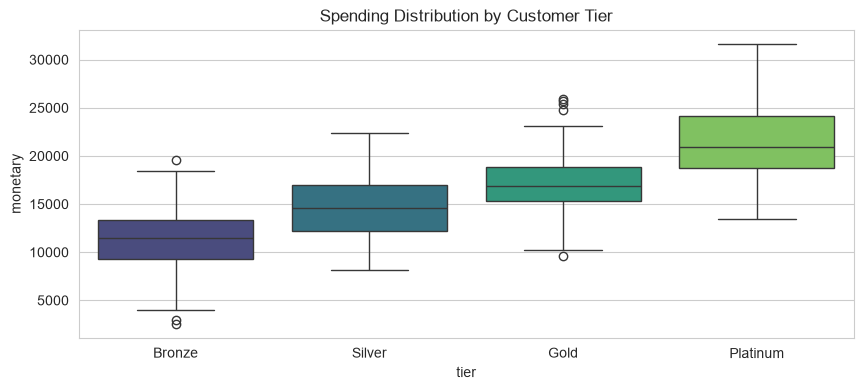

In [8]:
tier_order = ['Bronze','Silver','Gold','Platinum']
plt.figure(figsize=(10, 4))
sns.boxplot(data=scoring, x='tier', y='monetary', order=tier_order, palette='viridis')
plt.title('Spending Distribution by Customer Tier')
plt.savefig('../data/sample/tier_spending.png', dpi=100)
plt.show()

## 5. สรุป

✅ คำนวณ RFM, CLV (historical + predictive) และ Customer Scoring สำเร็จ — จัดลำดับลูกค้าเป็น 4 tiers พร้อมนำไปใช้ต่อยอด